# Preparation

In [1]:
# Required libraries
import os
import requests
import torch
import torch.nn as nn
from torch.nn import functional as F
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, AutoMinorLocator
import numpy as np
import time

In [2]:
def print_progress(step, total_steps, loss=None, extra=""):
    # Simple progress bar
    bar_width = 30
    frac = step / total_steps
    filled = int(bar_width * frac)
    bar = "=" * filled + "-" * (bar_width - filled)

    msg = f"\r[{bar}] {step:>6}/{total_steps} ({frac*100:5.1f}%)"
    if loss is not None:
        msg += f"  loss={loss:.4f}"
    if extra:
        msg += f"  {extra}"
    print(msg, end="", flush=True)

In [3]:
def COLORS():
    return {
    "red":   "#D17477",  # red
    "yellow":"#FFDD11",  # yellow
    "blue":  "#5289bb",  # blue
    "green": "#78bb75",  # green
}

def plot_loss(loss_list, save_path='results/result.pdf', figsize=(7, 4), color = COLORS()['red'], show_plot=True):
    steps = np.arange(1, len(loss_list) + 1)
    save_dir = os.path.dirname(save_path)
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)

    plt.figure(figsize=figsize)
    plt.plot(steps, loss_list, color=color, label='Training Loss', linewidth=1.5)

    ax = plt.gca()
    for s in ["top", "right", "bottom", "left"]:
        ax.spines[s].set_visible(True)
    ax.tick_params(axis="both", which="both",
                top=True, right=True, bottom=True, left=True,
                labeltop=False, labelright=False,
                direction="in")
    # 主刻度设置
    ax.xaxis.set_major_locator(MaxNLocator(nbins=8, integer=True))  # epoch 通常用整数
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
    # 次刻度设置
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))

    ticks = list(ax.get_xticks())
    if 1 not in ticks:
        ticks.append(1)
    if steps[-1] not in ticks:
        ticks.append(steps[-1])
    ticks = sorted(set(int(t) for t in ticks if t >= steps[0]))  # 去掉 <1 的，确保整数
    ax.set_xticks(ticks)

    # 网格（主/次都画一点，便于读数）
    ax.grid(True, which="major", linestyle="--", linewidth=0.8, alpha=0.35)
    ax.grid(True, which="minor", linestyle="--", linewidth=0.5, alpha=0.18)

    ax.set_xlim(left=steps[0], right=steps[-1])  # left=1, right=max step
    ax.margins(x=0)             # 去掉默认留白

    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.title('Training Loss over Time')
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, transparent=True)
    if show_plot:
        plt.show()

# Data

In [4]:
# download dataset  (tiny shakespeare dataset)
if '__file__' in globals(): # 
    base_dir = os.path.dirname(__file__)
else:
    base_dir = os.getcwd()

input_file_path = os.path.join(base_dir, 'input.txt') # build local path
if not os.path.exists(input_file_path):
    data_url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
    with open(input_file_path, 'w') as f:
        f.write(requests.get(data_url).text)

In [5]:
# separate train & validation dataset
with open(input_file_path, 'r', encoding='utf-8') as f:
    data = f.read()
n = len(data) # data length = 1115394
train_data = data[:int(n*0.9)] # first 90% for training
val_data = data[int(n*0.9):]   # last 10% for validation

In [6]:
# build character level vocabulary
chars = list(sorted(set(data)))
vocab_size = len(chars) # 65 characters in total
print(''.join(chars))
print(f'{len(chars)} unique characters found')


 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
65 unique characters found


In [7]:
# create character to integer mapping and vice versa
cha2ite = { ch:i for i,ch in enumerate(chars) }
ite2cha = { i:ch for i,ch in enumerate(chars) }
print(cha2ite)
encode = lambda s: [cha2ite[c] for c in s]        # encoder: take a String, outout the integer of the Characters in the String
decode = lambda l: "".join(ite2cha[i] for i in l) # decoder: take a list of integers, output the corresponding String

data = torch.tensor(encode(data), dtype=torch.long)             # torch.Size([1115394])
train_data = torch.tensor(encode(train_data), dtype=torch.long) # torch.Size([1003854])
val_data = torch.tensor(encode(val_data), dtype=torch.long)     #  torch.Size([111540])
print(data.shape, train_data.shape, val_data.shape)

{'\n': 0, ' ': 1, '!': 2, '$': 3, '&': 4, "'": 5, ',': 6, '-': 7, '.': 8, '3': 9, ':': 10, ';': 11, '?': 12, 'A': 13, 'B': 14, 'C': 15, 'D': 16, 'E': 17, 'F': 18, 'G': 19, 'H': 20, 'I': 21, 'J': 22, 'K': 23, 'L': 24, 'M': 25, 'N': 26, 'O': 27, 'P': 28, 'Q': 29, 'R': 30, 'S': 31, 'T': 32, 'U': 33, 'V': 34, 'W': 35, 'X': 36, 'Y': 37, 'Z': 38, 'a': 39, 'b': 40, 'c': 41, 'd': 42, 'e': 43, 'f': 44, 'g': 45, 'h': 46, 'i': 47, 'j': 48, 'k': 49, 'l': 50, 'm': 51, 'n': 52, 'o': 53, 'p': 54, 'q': 55, 'r': 56, 's': 57, 't': 58, 'u': 59, 'v': 60, 'w': 61, 'x': 62, 'y': 63, 'z': 64}
torch.Size([1115394]) torch.Size([1003854]) torch.Size([111540])


In [8]:
# test the encoder and decoder
print(encode("Hello World!"))
print(decode([20, 43, 50, 50, 53, 1, 35, 53, 56, 50, 42, 2]))

[20, 43, 50, 50, 53, 1, 35, 53, 56, 50, 42, 2]
Hello World!


In [9]:
# time dimension:  chunk
block_size = 4
x = data[:block_size]
y = data[1:block_size+1]

for t in range(block_size):
    content = x[:t+1]
    target = y[t]
    print(f"based on content {content}, want to predict {target}")

based on content tensor([18]), want to predict 47
based on content tensor([18, 47]), want to predict 56
based on content tensor([18, 47, 56]), want to predict 57
based on content tensor([18, 47, 56, 57]), want to predict 58


In [10]:
# generate mini-batches
torch.manual_seed(1337)
block_size = 8
batch_size = 4

def get_batch(data_source='train'):
    # generate a small batch of data of inputs x and targets y
    data = train_data if data_source == 'train' else val_data
    idx = torch.randint(len(data)-block_size, (batch_size,)) # randomly pick batch_size starting points for the chunks
    x = torch.stack([data[i:i+block_size] for i in idx]) # (batch_size, block_size)
    y = torch.stack([data[i+1:i+block_size+1] for i in idx]) # (batch_size, block_size)
    return x, y

xb, yb = get_batch('train')
print('inputs:')
print(xb)
print('targets:')
print(yb)

for i in range(batch_size):
    for t in range(block_size):
        context = xb[i,:t+1]
        target = yb[i,t]
        print(f'for batch {i} at time {t}, based on context {context} want to predict {target}')

inputs:
tensor([[24, 43, 58,  5, 57,  1, 46, 43],
        [44, 53, 56,  1, 58, 46, 39, 58],
        [52, 58,  1, 58, 46, 39, 58,  1],
        [25, 17, 27, 10,  0, 21,  1, 54]])
targets:
tensor([[43, 58,  5, 57,  1, 46, 43, 39],
        [53, 56,  1, 58, 46, 39, 58,  1],
        [58,  1, 58, 46, 39, 58,  1, 46],
        [17, 27, 10,  0, 21,  1, 54, 39]])
for batch 0 at time 0, based on context tensor([24]) want to predict 43
for batch 0 at time 1, based on context tensor([24, 43]) want to predict 58
for batch 0 at time 2, based on context tensor([24, 43, 58]) want to predict 5
for batch 0 at time 3, based on context tensor([24, 43, 58,  5]) want to predict 57
for batch 0 at time 4, based on context tensor([24, 43, 58,  5, 57]) want to predict 1
for batch 0 at time 5, based on context tensor([24, 43, 58,  5, 57,  1]) want to predict 46
for batch 0 at time 6, based on context tensor([24, 43, 58,  5, 57,  1, 46]) want to predict 43
for batch 0 at time 7, based on context tensor([24, 43, 58,

# Model

In [11]:
import torch
import torch.nn as nn # neural network module
from torch.nn import functional as F # frequently used functions module
torch.manual_seed(1337)

class BiGramLanguageModel(nn.Module):
    def __init__(self, vocab_size, embed_size): # initialize the model
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, embed_size) # (size of the dictionary of embeddings, size of each embedding vector)
    
    def forward(self, idx, target=None): # index and target are both (batch_size, block_size) == (B, T)
        logits = self.token_embedding_table(idx) # (batch_size, block_size (time), embed_size (class)) == (B, T, C)

        if target is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            target = target.view(B*T) # or target = target.reshape(-1)

            loss = F.cross_entropy(logits, target)

        return logits, loss
    
    def generate(self, idx, max_new_tokens):
        # idx is (batch_size, block_size) == (B, T)
        for _ in range(max_new_tokens):
            logits, _ = self(idx) # (B, T, C)
            logits = logits[:, -1, :] # (B, C), focus only on the last time step in the chunk
            probs = F.softmax(logits, dim=-1) # (B, C), dim=-1 means along the class dimension
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx

In [12]:
test_idx = torch.tensor([[4], [3]])
test_target = torch.tensor([[2], [4]])
test_model = BiGramLanguageModel(vocab_size, embed_size=vocab_size)
test_logits, test_loss = test_model(test_idx, test_target)
print(test_logits)

print("\nGenerating new tokens:")
test_outputs = test_model.generate(test_idx, max_new_tokens=20)
print(test_outputs)

print("\nDecoding generated tokens:")
for i in range(test_outputs.shape[0]):
    print("Batch", i, ":", decode(test_outputs[i].tolist()))

tensor([[ 8.1485e-01, -6.4297e-02,  1.4237e+00,  2.6173e-01, -1.8528e+00,
          2.0186e-01, -1.1787e+00, -1.0358e-01, -1.7830e+00, -8.3234e-01,
         -4.3462e-01, -1.2480e+00, -2.8797e-01,  8.8086e-01, -7.1896e-01,
          1.7449e-01,  7.5198e-01, -6.2878e-02, -7.1113e-01,  9.8100e-01,
         -7.2443e-01, -1.5010e+00, -2.8348e+00, -2.8272e+00, -1.7358e-01,
          5.1187e-02, -6.5764e-01, -2.5729e+00,  2.1011e-02,  1.0060e+00,
         -1.2492e+00,  2.4413e-01, -6.3866e-01, -3.1861e-01, -1.2942e+00,
         -1.0726e+00,  2.2901e-01, -9.0008e-01,  6.6140e-01,  5.1178e-01,
          6.7622e-01, -1.3639e+00,  5.4861e-01,  8.9502e-02,  3.5746e-01,
         -1.6521e+00, -7.5838e-01,  6.9533e-02,  9.9369e-01, -2.8205e-01,
          1.1088e+00, -1.9881e+00, -1.3916e+00,  1.2734e+00, -1.1732e+00,
          5.8200e-01, -1.3185e+00,  7.8586e-01, -1.1501e+00,  1.3132e+00,
          2.2007e+00, -2.1945e-01,  5.4272e-01,  2.5867e+00, -4.6874e-01],
        [ 1.3915e+00,  1.0785e+00, -6

In [13]:
model = BiGramLanguageModel(vocab_size, embed_size=vocab_size)
logits, loss = model(xb, yb)

In [14]:
print(logits.shape) # (batch_size * block_size, vocab_size) == (B*T, C)
print(loss)

torch.Size([32, 65])
tensor(4.7368, grad_fn=<NllLossBackward0>)


# Train

In [15]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3) # lr=1e-3 is for small model, but for larger model, use lr=1e-4 or 1e-5

In [16]:
batch_size = 32 # increase batch size for faster training
steps = 10000
loss_list = []
start_time = time.time()
for step in range(steps):
    xb, yb = get_batch('train')
    
    # evaluate the loss
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    loss_list.append(loss.item())
    if (step+1) % 100 == 0 or step == 0:
        print_progress(step+1, steps, loss.item())
end_time = time.time()
print(f'\nTraining completed in {end_time - start_time:.2f} seconds.') # machine with M1 Pro: ~7.7 seconds

[==============================]  10000/10000 (100.0%)  loss=2.3059
Training completed in 7.63 seconds.


Final training loss: 2.3059


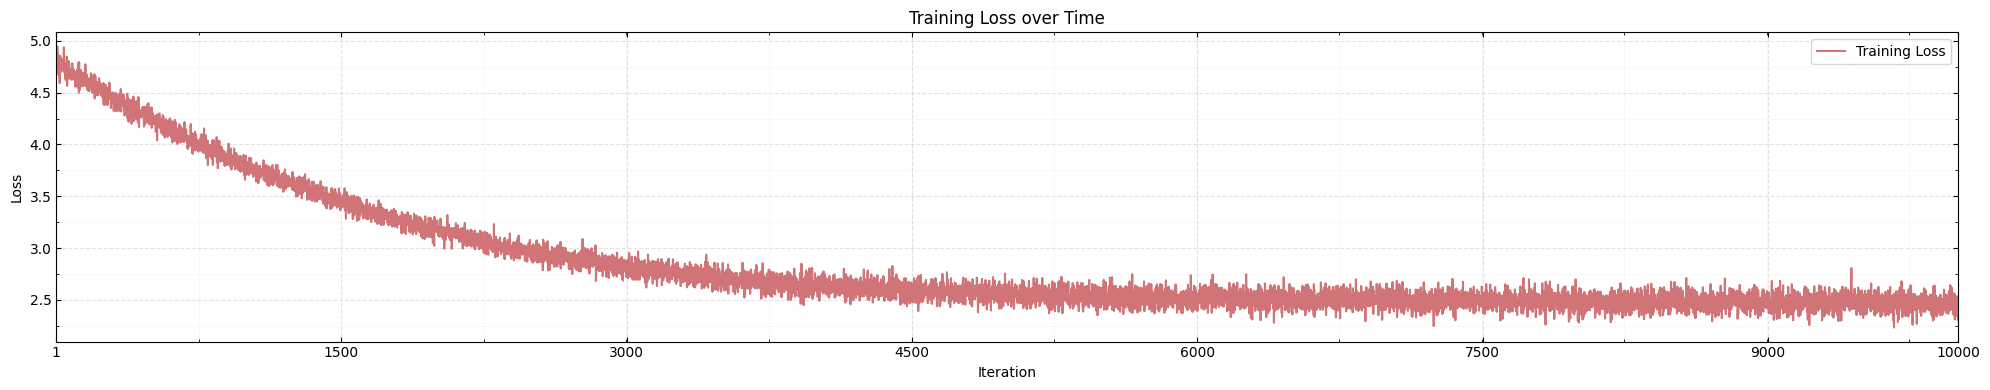

In [17]:
print(f'Final training loss: {loss.item():.4f}')
plot_loss(loss_list, save_path='results/training_loss_1.pdf', figsize=(20, 4), color = COLORS()['red'], show_plot=True)

In [18]:
test_idx = torch.tensor([[4], [3]])
test_target = torch.tensor([[2], [4]])
test_logits, test_loss = model(test_idx, test_target)
test_outputs = model.generate(test_idx, max_new_tokens=100)
for i in range(test_outputs.shape[0]):
    print("Batch", i, ":", decode(test_outputs[i].tolist()))

Batch 0 : &ur mucarien, llt my sed t as sprtr itowitaterrt o tVreme;

Bu hy it t cr wensh aber, inouanch f n ma
Batch 1 : $-ne wonotofond.
W:
Therst nomerod wit ond s, rereley o Thiotopr y bro d hetrtisoorar; le beve y m ve


# The mathematical trick in self-attention

## small introduction

In [30]:
# consider the following toy example
torch.manual_seed(43)
B, T, C = 2, 3, 2
x = torch.randn(B, T, C)
print(f"Input x (shape: {x.shape}):")
print(x)

Input x (shape: torch.Size([2, 3, 2])):
tensor([[[-0.6484, -0.7058],
         [ 0.6432,  1.4788],
         [ 1.1918, -0.1446]],

        [[ 0.4847,  0.6921],
         [-1.3929,  0.7623],
         [ 0.8387, -1.0450]]])


In [31]:
# in self-attention, for each token, we want them to talk to each other, but only to the previous tokens
# one very simple way to implement this is to average the previous tokens
xbow = torch.zeros((B, T, C))
for batch in range(B):
    for time in range(T):
        xprev = x[batch, :time+1] # (time+1, C)
        xbow[batch, time] = torch.mean(xprev, dim=0) # dim=0 is to average over the time dimension

print(f"\nBag-of-words representation xbow (shape: {xbow.shape}):")
print(xbow)


Bag-of-words representation xbow (shape: torch.Size([2, 3, 2])):
tensor([[[-0.6484, -0.7058],
         [-0.0026,  0.3865],
         [ 0.3956,  0.2094]],

        [[ 0.4847,  0.6921],
         [-0.4541,  0.7272],
         [-0.0232,  0.1365]]])


In [32]:
# more advanced: use attention weights to do weighted average of previous tokens
# but from a very simple matrix multiplication
torch.manual_seed(42)
a = torch.ones(3, 3)
b = torch.randint(0, 10, (3, 2)).float()
c = a @ b  # (3, 2)
print(f"a=")
print(a)
print(f"b=")
print(b)
print(f"c = a @ b =")
print(c)

a=
tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]])
b=
tensor([[2., 7.],
        [6., 4.],
        [6., 5.]])
c = a @ b =
tensor([[14., 16.],
        [14., 16.],
        [14., 16.]])


we can see the first element in c is the sum over the first row elemently times the first column in b

In [33]:
# now we can use triangular matrix to implement the attention masking
torch.manual_seed(42)
a = torch.tril(torch.ones(3, 3)) # lower triangular matrix
b = torch.randint(1, 10, (3, 2)).float()
c = a @ b  # (3, 2)
print(f"a=")
print(a)
print(f"b=")
print(b)
print(f"c = a @ b =")
print(c)
# we can see in c,  the first row only attends to the first row of b, the second row attends to the first two rows of b, and the third row attends to all three rows of b

a=
tensor([[1., 0., 0.],
        [1., 1., 0.],
        [1., 1., 1.]])
b=
tensor([[7., 6.],
        [8., 5.],
        [1., 3.]])
c = a @ b =
tensor([[ 7.,  6.],
        [15., 11.],
        [16., 14.]])


In [34]:
# however, this is not normalized attention, we can normalize the rows of a to make them sum to 1
a = a / a.sum(dim=1, keepdim=True) # normalize the rows (dim=1) (dim=0: columns)
print(f"\nNormalized a=")
print(a)
b = torch.randint(1, 10, (3, 2)).float()
c = a @ b  # (3, 2)
print(f"b=")
print(b)
print(f"c = a @ b =")
print(c)


Normalized a=
tensor([[1.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000],
        [0.3333, 0.3333, 0.3333]])
b=
tensor([[8., 6.],
        [5., 3.],
        [5., 5.]])
c = a @ b =
tensor([[8.0000, 6.0000],
        [6.5000, 4.5000],
        [6.0000, 4.6667]])


## weighted sum

In [35]:
torch.manual_seed(43)
B, T, C = 2, 3, 2
x = torch.randn(B, T, C)
print(f"Input x (shape: {x.shape}):")
print(x)

Input x (shape: torch.Size([2, 3, 2])):
tensor([[[-0.6484, -0.7058],
         [ 0.6432,  1.4788],
         [ 1.1918, -0.1446]],

        [[ 0.4847,  0.6921],
         [-1.3929,  0.7623],
         [ 0.8387, -1.0450]]])


In [36]:
w = torch.tril(torch.ones(T, T))
w = w / w.sum(dim=1, keepdim=True)
print(f"\nAttention mask w (shape: {w.shape}):")
print(w)


Attention mask w (shape: torch.Size([3, 3])):
tensor([[1.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000],
        [0.3333, 0.3333, 0.3333]])


In [37]:
# version 1: explicit loops
xbow = torch.zeros((B, T, C))
for batch in range(B):
    for time in range(T):
        xprev = x[batch, :time+1] # (time+1, C)
        xbow[batch, time] = torch.mean(xprev, dim=0)
print(f"\nBag-of-words representation xbow (shape: {xbow.shape}):")
print(xbow)


Bag-of-words representation xbow (shape: torch.Size([2, 3, 2])):
tensor([[[-0.6484, -0.7058],
         [-0.0026,  0.3865],
         [ 0.3956,  0.2094]],

        [[ 0.4847,  0.6921],
         [-0.4541,  0.7272],
         [-0.0232,  0.1365]]])


In [38]:
# version 2: matrix multiplication
# @ will automatically broadcast the batch dimension
w = torch.tril(torch.ones(T, T))
w = w / w.sum(dim=1, keepdim=True)
xbow2 = w @ x # (T, T) @ (B, T, C)--> (B, T, T) @ (B, T, C) --> (B, T, C)
print(f"\nBag-of-words representation xbow (shape: {xbow2.shape}):")
print(xbow2)
torch.allclose(xbow, xbow2)


Bag-of-words representation xbow (shape: torch.Size([2, 3, 2])):
tensor([[[-0.6484, -0.7058],
         [-0.0026,  0.3865],
         [ 0.3956,  0.2094]],

        [[ 0.4847,  0.6921],
         [-0.4541,  0.7272],
         [-0.0232,  0.1365]]])


True

In [39]:
# version 3: use softmax
tril = torch.tril(torch.ones(T, T))
w = torch.zeros(T, T)
w = w.masked_fill(tril == 0, float('-inf'))
print(f"\nAttention weights w before softmax (shape: {w.shape}):")
print(w)
w = F.softmax(w, dim=-1) # dim=-1 means along the last dimension, i.e., the columns
print(f"\nAttention weights w after softmax (shape: {w.shape}):")
print(w)
xbow3 = w @ x
print(f"\nBag-of-words representation xbow3 (shape: {xbow3.shape}):")
print(xbow3)
torch.allclose(xbow, xbow3)


Attention weights w before softmax (shape: torch.Size([3, 3])):
tensor([[0., -inf, -inf],
        [0., 0., -inf],
        [0., 0., 0.]])

Attention weights w after softmax (shape: torch.Size([3, 3])):
tensor([[1.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000],
        [0.3333, 0.3333, 0.3333]])

Bag-of-words representation xbow3 (shape: torch.Size([2, 3, 2])):
tensor([[[-0.6484, -0.7058],
         [-0.0026,  0.3865],
         [ 0.3956,  0.2094]],

        [[ 0.4847,  0.6921],
         [-0.4541,  0.7272],
         [-0.0232,  0.1365]]])


True

In [ ]:
# version 4: self-attention
B, T, C = 2, 3, 2
torch.manual_seed(42)
x = torch.randn(B, T, C)

# a single Head self-attention
head_size = 16 # how many parameters per head, denoted as H
# based on the information (vector) of each token, construct key, query, value vectors
key = nn.Linear(C, head_size, bias=False)   # key: what I have
query = nn.Linear(C, head_size, bias=False) # query: what to look for
value = nn.Linear(C, head_size, bias=False) # value: what I want to deliver to you

k = key(x)   # (B, T, H)
q = query(x) # (B, T, H)
v = value(x) # (B, T, H)

w = q @ k.transpose(-2, -1) # (B, T, H) * (B, H, T) --> (B, T, T)
print(f"\nRaw attention scores w (shape: {w.shape}):")
print(w)

tril = torch.tril(torch.ones(T, T))
w = w.masked_fill(tril == 0, float('-inf'))
w = F.softmax(w, dim=-1)
print(f"\nAttention weights w after masking and softmax (shape: {w.shape}):")
print(w)

out = w @ v # (B, T, T) @ (B, T, H) --> (B, T, H)
print(f"\nSelf-attention output (shape: {out.shape}):")
print(out)



Raw attention scores w (shape: torch.Size([2, 3, 3])):
tensor([[[-0.1172, -0.1076,  0.3458],
         [-0.0822, -0.0757,  0.2421],
         [ 0.3898,  0.3577, -1.1510]],

        [[-3.2395, -1.1535, -1.9302],
         [-0.6778, -0.2440, -0.4102],
         [-0.7860, -0.2863, -0.4837]]], grad_fn=<UnsafeViewBackward0>)

Attention weights w after masking and softmax (shape: torch.Size([2, 3, 3])):
tensor([[[1.0000, 0.0000, 0.0000],
         [0.4984, 0.5016, 0.0000],
         [0.4582, 0.4437, 0.0981]],

        [[1.0000, 0.0000, 0.0000],
         [0.3932, 0.6068, 0.0000],
         [0.2499, 0.4119, 0.3381]]], grad_fn=<SoftmaxBackward0>)

Self-attention output (shape: torch.Size([2, 3, 16])):
tensor([[[-0.0924,  0.0271,  0.2038, -0.2213,  0.1873, -0.1725, -0.1136,
          -0.0975, -0.0566, -0.2521, -0.2664,  0.2552, -0.0116, -0.1867,
          -0.0429, -0.1571],
         [-0.0631,  0.0103,  0.2067, -0.2142,  0.1419, -0.1945, -0.0838,
          -0.1189, -0.0821, -0.2412, -0.2576,  0.2257, -

## Normalization

In [28]:
B, T, H = 1, 4, 30
k = torch.randn(B, T, H)
q = torch.randn(B, T, H)
w1 = q @ k.transpose(-2, -1)
w2 = q @ k.transpose(-1, -2) * H**-0.5
print(f"k.var(): {k.var()}")
print(f"q.var(): {q.var()}")
print(f"w1.var(): {w1.var()}")
print(f"w2.var(): {w2.var()}")

k.var(): 0.9997282028198242
q.var(): 1.0019570589065552
w1.var(): 27.462677001953125
w2.var(): 0.9154225587844849


In [45]:
w = torch.tensor([1.0, 2.0, 3.0])
print(f"w.var(): {w.var()}")
F.softmax(w, dim=-1)

w.var(): 1.0


tensor([0.0900, 0.2447, 0.6652])

In [44]:
print(f"w*100.var(): {(w*100).var()}")
F.softmax(w*100, dim=-1)

w*100.var(): 10000.0


tensor([0.0000e+00, 3.7835e-44, 1.0000e+00])